# Monte Carlo PnL Simulation

This notebook simulates possible PnL paths by fitting to the historical `pnl` values in a CSV (e.g., `vol_gp\artifacts\variance_proxy_trades.csv`).
The simulation uses **bootstrap resampling** of observed PnL by default, so it matches the empirical distribution.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


## Config


In [32]:
CSV_PATH = r"..\return_gp\artifacts\return_gp_trades.csv"
N_PATHS = 300
N_STEPS = 252
SEED = 7

# Choose how to fit pnl distribution
FIT_METHOD = "normal"  # "bootstrap" or "normal"


In [33]:
df = pd.read_csv(CSV_PATH)
if "pnl" not in df.columns:
    raise ValueError("CSV must include a 'pnl' column.")

pnl = df["pnl"].dropna().astype(float).to_numpy()
if pnl.size == 0:
    raise ValueError("No pnl values found after dropping NaNs.")

pd.Series(pnl).describe()


count    229.000000
mean       0.937916
std       10.564910
min      -35.428841
25%       -5.924245
50%        0.728135
75%        7.394713
max       47.228499
dtype: float64

In [34]:
rng = np.random.default_rng(SEED)

if FIT_METHOD == "bootstrap":
    # Empirical resampling of observed pnl values
    samples = rng.choice(pnl, size=(N_STEPS, N_PATHS), replace=True)
elif FIT_METHOD == "normal":
    # Parametric fit to mean/std of pnl
    mu = pnl.mean()
    sigma = pnl.std(ddof=1)
    samples = rng.normal(mu, sigma, size=(N_STEPS, N_PATHS))
else:
    raise ValueError("FIT_METHOD must be 'bootstrap' or 'normal'.")

paths = samples.cumsum(axis=0)
paths.shape


(252, 300)

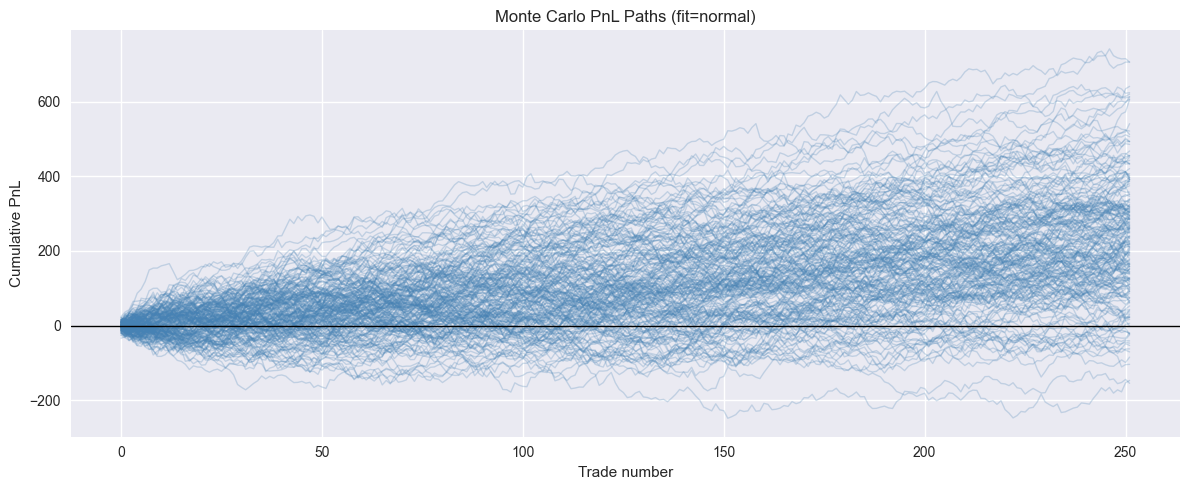

In [35]:
# Plot a subset of cumulative PnL paths
plot_n = min(200, N_PATHS)
idx = rng.choice(N_PATHS, size=plot_n, replace=False)

plt.figure(figsize=(12, 5))
plt.plot(paths[:, idx], color="steelblue", alpha=0.25, lw=1)
plt.axhline(0, color="black", lw=1)
plt.title(f"Monte Carlo PnL Paths (fit={FIT_METHOD})")
plt.xlabel("Trade number")
plt.ylabel("Cumulative PnL")
plt.tight_layout()


count    300.000000
mean     235.928148
std      161.778768
min     -154.363786
25%      128.168895
50%      237.101657
75%      323.930371
max      705.654763
dtype: float64

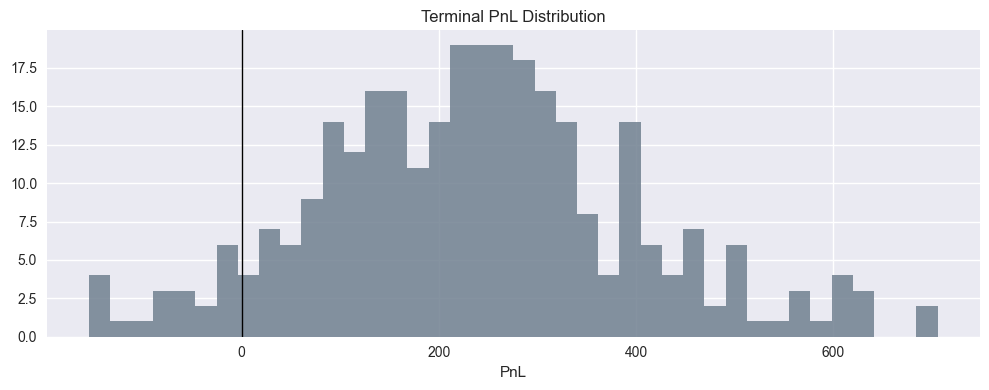

In [36]:
# Terminal PnL distribution
terminal = paths[-1]

plt.figure(figsize=(10, 4))
plt.hist(terminal, bins=40, color="slategray", alpha=0.85)
plt.axvline(0, color="black", lw=1)
plt.title("Terminal PnL Distribution")
plt.xlabel("PnL")
plt.tight_layout()

pd.Series(terminal).describe()
